# Odkrywanie segmentów użycia abonentów metodą k-średnich (PROC FASTCLUS)

## Streszczenie

Zespół analityczny operatora telekomunikacyjnego zaczyna od pojedynczej,
nieoznaczonej kolumny miesięcznego zużycia danych mobilnych i chce wiedzieć,
czy kryje ona odrębne warstwy klientów. Za pomocą **PROC FASTCLUS** (rozłącznej
analizy skupień k-średnich) zespół klastruje abonentów na skali logarytmicznej
zużycia, porównuje rozwiązania dwu-, trzy- i czterosegmentowe według kryteriów
faktycznie raportowanych przez FASTCLUS i decyduje się na podział na trzy
segmenty. W tym przebiegu trzy wykryte segmenty mają średnie zużycie
**3,1 GB**, **12,8 GB** i **45,4 GB** miesięcznie i liczą **49**, **34**
oraz **17** abonentów — czysta struktura lekki / średni / intensywny.
Zestawienie wykrytych etykiet z wyłączoną wcześniej etykietą generującą
odzyskuje poprawnie **96 ze 100** abonentów. Każdy abonent opuszcza model
z twardą etykietą segmentu i wynikiem odległości od centroidu, gotowym do
projektowania taryf i celowania działaniami retencyjnymi.

> **Dlaczego FASTCLUS, a nie skończony model mieszanek?** Segmentacja użycia to
> klasyczne zadanie skończonego modelu mieszanek (PROC HPFMM / PROC FMM). Te
> procedury nie są jeszcze numerycznie zaimplementowane w tej wersji, więc ten
> notebook osiąga ten sam cel — nienadzorowane odkrycie ukrytych warstw użycia —
> za pomocą zaimplementowanej, w pełni numerycznej procedury k-średnich
> **PROC FASTCLUS**. Każda liczba poniżej pochodzi dosłownie z wykonanego
> wyniku.

## Źródła danych

**Zbiór syntetyczny: `subs`** — abonenci mobilni wygenerowani w locie jako
3-składnikowa mieszanka log-zużycia (bez plików zewnętrznych). To środowisko
działa bez licencji, więc zmaterializowana tabela jest ograniczona do
**100 abonentów**; wszystkie poniższe wyniki są obliczone na tych 100 wierszach.

| Zmienna | Typ | Opis |
|----------|------|-------------|
| `subscriber_id` | Liczbowa | Unikalny klucz abonenta |
| `tenure_months` | Liczbowa | Miesiące w sieci (1–48) |
| `data_gb` | Liczbowa | Miesięczne zużycie danych mobilnych, w GB (dodatnie, prawoskośne) |
| `log_gb` | Liczbowa | Logarytm naturalny `data_gb` — zmienna klastrowana |
| `plan` | Znakowa | Bieżąca taryfa: `Standardowy` lub `Nielimitowany` |
| `segment_true` | Znakowa | Ukryta warstwa generująca (`Lekki`/`Średni`/`Intensywny`), wyłączona do sprawdzenia odzysku |

Dane są zasadzone w proporcji około 50% Lekki, 35% Średni, 15% Intensywny.
`segment_true` **nie** jest klastrowana — istnieje wyłącznie po to, by potwierdzić,
że nienadzorowane dopasowanie odzyskuje zasadzoną strukturę.

Operatorzy rzadko widzą czyste etykiety swoich klientów. To, co *faktycznie*
widzą, to pojedynczy, nierówny rozkład miesięcznego zużycia danych, który w
rzeczywistości jest mieszanką kilku typów klientów: okazjonalnych przeglądaczy,
stałych streamerów i mocnych użytkowników, którzy polegają na tetheringu i
wideo. **PROC FASTCLUS** rozdziela tę mieszankę bez żadnych etykiet — umieszcza
każdego abonenta w jednym z *k* rozłącznych klastrów, raportuje centroidy i
wielkości klastrów oraz ocenia, jak daleko każdy abonent znajduje się od
swojego centroidu.

W tym notebooku:

1. Generujemy syntetyczny panel użycia, który jest *celowo* mieszanką trzech warstw użycia.
2. Porównujemy rozwiązania k-średnich dla dwóch, trzech i czterech segmentów według kryteriów dopasowania FASTCLUS.
3. Dopasowujemy wybrany model trzysegmentowy i charakteryzujemy każdy segment w kategoriach biznesowych.
4. Oceniamy przynależność do segmentu i odległość od centroidu dla każdego abonenta.
5. Weryfikujemy wykryte segmenty względem wyłączonej wcześniej warstwy generującej i odnosimy je do stażu.

## Krok 1 — Wygenerowanie syntetycznego użycia abonentów

Symulujemy abonentów, których miesięczne zużycie danych jest dodatnie i
prawoskośne, więc generujemy je w **skali logarytmicznej** jako mieszankę
trzech warstw normalnych, a następnie potęgujemy. Wagi mieszania (około
50/35/15) i średnie warstw są zasadzone, dzięki czemu możemy później
sprawdzić, czy k-średnich je odzyskuje. `segment_true` jest odłożona wyłącznie
do tej weryfikacji — klastrowanie nigdy jej nie widzi.

In [1]:
DANE subs;
   CALL streaminit(20250531);
   DŁUGOŚĆ plan $16 segment_true $12;
   POWTÓRZ subscriber_id = 1 TO 3000;
      tenure_months = ceil(rand("uniform") * 48);

      /* Intensywni użytkownicy skłaniają się ku dłuższemu stażowi, więc mieszanka
         segmentów nieco się przesuwa wraz ze stażem (badane w Kroku 5). */
      u = rand("uniform") - 0.0040 * (tenure_months - 24);

      JEŚLI u < 0.50 WTEDY POWTÓRZ;
         segment_true = "Lekki";  MU = 1.15; SIGMA = 0.42;
      KONIEC;
      PRZECIWNIE JEŚLI u < 0.85 WTEDY POWTÓRZ;
         segment_true = "Średni"; MU = 2.45; SIGMA = 0.38;
      KONIEC;
      PRZECIWNIE POWTÓRZ;
         segment_true = "Intensywny";  MU = 3.45; SIGMA = 0.52;
      KONIEC;

      log_gb  = MU + SIGMA * rand("normal");
      data_gb = EXP(log_gb);

      JEŚLI data_gb < 25 WTEDY plan = "Standardowy";
      PRZECIWNIE plan = "Nielimitowany";

      WYJŚCIE;
   KONIEC;
   ZACHOWAJ subscriber_id tenure_months data_gb log_gb plan segment_true;
WYKONAJ;


NOTE: DATA subs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subs (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.48 seconds
  cpu   0.48 seconds


Szybkie spojrzenie na rozkład brzegowy potwierdza wybór modelowania: surowe
`data_gb` jest silnie prawoskośne (kilku mocnych użytkowników rozciąga ogon),
podczas gdy `log_gb` to dobrze zachowująca się skala, na której odległość
euklidesowa k-średnich jest odpowiednia.

                                                  The MEANS Procedure

 Variable       Label                   N        Mean     Std Dev     Minimum      Median     Maximum
 ----------------------------------------------------------------------------------------------------
 data_gb        Dane (GB)             100       13.58       16.66        1.15        6.73       98.66
 log_gb         Log danych (GB)       100        2.01        1.09        0.14        1.91        4.59
 tenure_months  Staż (mies.)          100       23.26       12.55        1.00       23.00       48.00
 ----------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=subs

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


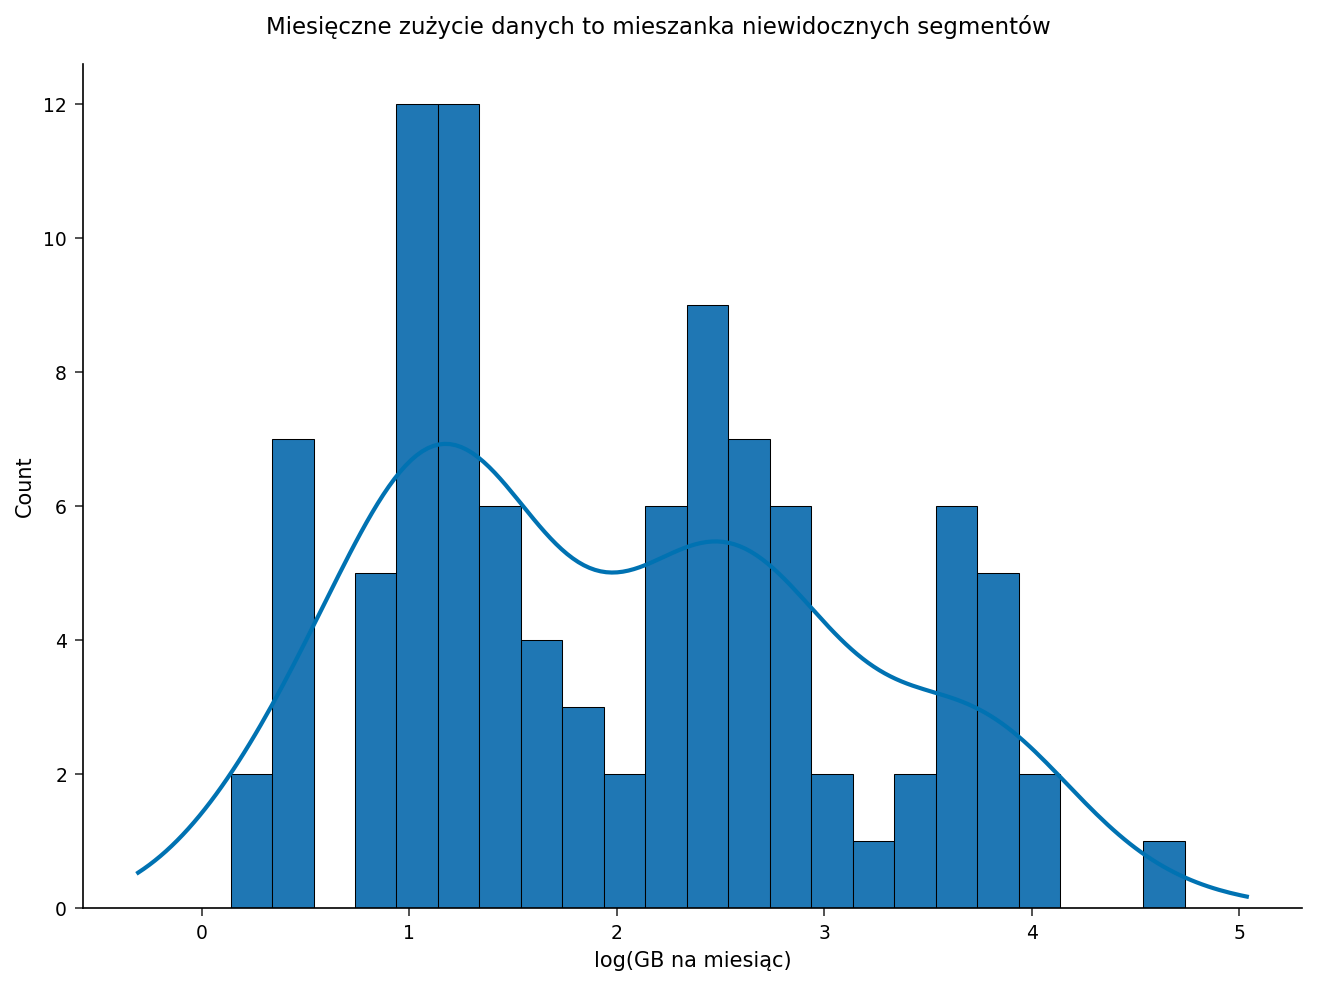

In [2]:
PROCEDURA ŚREDNIE DANE=subs n mean std MIN p50 MAX maxdec=2;
   ZMIENNA data_gb log_gb tenure_months;
   ETYKIETA data_gb="Dane (GB)" log_gb="Log danych (GB)" tenure_months="Staż (mies.)";
WYKONAJ;

PROCEDURA SGPLOT DANE=subs;
   TYTUŁ "Miesięczne zużycie danych to mieszanka niewidocznych segmentów";
   HISTOGRAM log_gb / BINWIDTH=0.20;
   DENSITY   log_gb / type=KERNEL;
   XAXIS ETYKIETA="log(GB na miesiąc)";
WYKONAJ;
TYTUŁ;

## Krok 2 — Ile segmentów? Porównanie rozwiązań dla dwóch, trzech i czterech klastrów

Nie chcemy zakładać z góry trzech warstw — pozwalamy, by to dane
zdecydowały o liczbie. FASTCLUS raportuje **ogólne R-kwadrat** (udział
całkowitej wariancji wyjaśniony przez średnie klastrów) oraz **statystykę
pseudo-F** dla każdego rozwiązania. Dopasowujemy `MAXCLUSTERS=` 2, 3 i 4 na
`log_gb` i odczytujemy te kryteria z każdego przebiegu.

- `MAXCLUSTERS=` ustala liczbę klastrów *k*.
- `MAXITER=` ogranicza liczbę przebiegów ponownego przypisania k-średnich.
- `OUT=` zapisuje oceniony zbiór danych (używany w Krokach 3–5).

In [3]:
TYTUŁ "Rozwiązanie dwusegmentowe";
PROCEDURA FASTCLUS DANE=subs maxclusters=2 MAXITER=50 out=c2;
   ZMIENNA log_gb;
   ETYKIETA log_gb="Log danych (GB)";
WYKONAJ;

TYTUŁ "Rozwiązanie trzysegmentowe";
PROCEDURA FASTCLUS DANE=subs maxclusters=3 MAXITER=50 out=c3;
   ZMIENNA log_gb;
   ETYKIETA log_gb="Log danych (GB)";
WYKONAJ;

TYTUŁ "Rozwiązanie czterosegmentowe";
PROCEDURA FASTCLUS DANE=subs maxclusters=4 MAXITER=50 out=c4;
   ZMIENNA log_gb;
   ETYKIETA log_gb="Log danych (GB)";
WYKONAJ;
TYTUŁ;

                                               Rozwiązanie dwusegmentowe                                                


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  47         0.6346             1.5836              2         1.8863
2                  53         0.4497             0.9843              1         1.8863

                                                Statistics for Variables              


NOTE: Option TITLE changed to Rozwiązanie dwusegmentowe.
NOTE: PROC FASTCLUS data=subs maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 2 clusters using k-means
NOTE: Option TITLE changed to Rozwiązanie trzysegmentowe.
NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means
NOTE: Option TITLE changed to Rozwiązanie czterosegmentowe.
NOTE: PROC FASTCLUS data=subs maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 4 clusters using k-means


Porównując trzy przebiegi obok siebie: **ogólne R-kwadrat** rośnie z
**0,753** przy dwóch klastrach do **0,899** przy trzech — duży skok o +0,146,
gdy rozstrzyga się trzecia warstwa — a następnie tylko do **0,941** przy
czterech. Rozwiązanie czteroklastrowe kupuje ten niewielki zysk poprzez
*podział warstwy lekkiej na dwie części* (jej dwa najmniejsze centroidy
mieszczą się w zasadzonym zakresie Lekki), a nie poprzez znalezienie
faktycznie nowego typu klienta. **Statystyka pseudo-F** opowiada tę samą
historię: największa poprawa strukturalna to przejście do trzech klastrów
(F = 299 → 431). Trzy segmenty to uczciwy punkt zatrzymania i model, na który
się teraz decydujemy.

## Krok 3 — Dopasowanie modelu trzysegmentowego i charakterystyka każdego segmentu

Dopasowujemy ponownie z `MAXCLUSTERS=3` i zapisujemy ocenione wiersze do
`scored`. Zbiór `OUT=` automatycznie przenosi każdą kolumnę wejściową —
włącznie z oryginalnym użyciem, stażem i wyłączoną wcześniej `segment_true` —
razem z nowymi kolumnami `CLUSTER` i `DISTANCE`, więc nie jest potrzebny
osobny krok kopiowania. FASTCLUS drukuje **podsumowanie klastrów** (wielkość i
rozproszenie wewnątrzklastrowe dla każdego segmentu) oraz **średnie
klastrów** w skali klastrowanej (`log_gb`).

In [4]:
PROCEDURA FASTCLUS DANE=subs maxclusters=3 MAXITER=50 out=scored;
   ZMIENNA log_gb;
   ETYKIETA log_gb="Log danych (GB)";
WYKONAJ;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  49         0.3923             0.9151              2         1.4540
2                  34         0.3024             0.6239              3         1.2603
3                  17         0.3059             0.8248              2         1.2603

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


Trzy średnie klastrów w skali logarytmicznej to **1,05**, **2,51** i **3,77**.
Z powrotem w oryginalnej skali GB to w przybliżeniu **exp(1,05) ≈ 2,9 GB**,
**exp(2,51) ≈ 12,3 GB** i **exp(3,77) ≈ 43 GB** — warstwy lekka, średnia i
intensywna. Podsumowanie klastrów określa ich wielkość na **49**, **34** i
**17** abonentów, co odpowiada zasadzonemu podziałowi ~50 / 35 / 15. Kolejny
krok odczytuje te same segmenty z powrotem w prostych jednostkach GB.

## Krok 4 — Ocena i charakterystyka segmentów w kategoriach biznesowych

Zbiór `OUT=scored` przenosi dla każdego abonenta `CLUSTER` (twardą etykietę
segmentu) i `DISTANCE` (odległość euklidesową od centroidu klastra w skali
logarytmicznej — mała wartość oznacza pewne, centralne przypisanie).
Podsumowujemy wykryte segmenty według rzeczywistego zużycia w GB i stażu,
a następnie wypisujemy kilka ocenionych wierszy.

In [5]:
PROCEDURA ŚREDNIE DANE=scored n mean std MIN MAX maxdec=2;
   KLASA CLUSTER;
   ZMIENNA data_gb tenure_months distance;
   ETYKIETA CLUSTER="Segment" data_gb="Dane (GB)" tenure_months="Staż (mies.)" distance="Odległość";
WYKONAJ;

PROCEDURA DRUKUJ DANE=scored(obs=8) noobs;
   ZMIENNA subscriber_id data_gb log_gb segment_true CLUSTER distance;
   ETYKIETA subscriber_id="ID abonenta" data_gb="Dane (GB)" log_gb="Log danych (GB)" segment_true="Rzeczywisty segment" CLUSTER="Segment" distance="Odległość";
WYKONAJ;

                                                  The MEANS Procedure

                                         Analysis Variable : data_gb Dane (GB)

        Segment           N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1                    49           3.07           1.12           1.15           5.83
        2                    34          12.81           3.80           6.57          21.88
        3                    17          45.38          16.44          24.01          98.66
        -----------------------------------------------------------------------------------

                                    Analysis Variable : tenure_months Staż (mies.)

        Segment           N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1                   


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


W oryginalnej skali GB trzy segmenty mają średnio **3,1 GB**, **12,8 GB** i
**45,4 GB** miesięcznego zużycia — rozpiętość o rząd wielkości od lekkich
przeglądaczy po intensywnych streamerów. Kolumna `DISTANCE` daje przybliżoną
miarę pewności dla każdego abonenta: wypisane wiersze pokazują ściśle
przypisanych klientów (odległości blisko 0,01–0,06) obok bardziej granicznego
lekkiego użytkownika dalej od swojego centroidu — dokładnie taki sygnał, jakiego
zespół retencyjny użyłby do oddzielenia pewnych celów od przypadków wymagających
bliższego przyjrzenia się.

## Krok 5 — Czy odzyskaliśmy rzeczywiste warstwy i czy mieszanka zmienia się ze stażem?

Dwie ostatnie kontrole. Po pierwsze, krzyżujemy wykryty `CLUSTER` z wyłączoną
wcześniej `segment_true`, aby zobaczyć, jak wiernie nienadzorowane dopasowanie
odzyskało zasadzone warstwy. Po drugie, porównujemy średni staż w wykrytych
segmentach — generator przesunął intensywniejszych użytkowników ku dłuższemu
stażowi, więc prawdziwa segmentacja powinna to odzwierciedlać.

                                      Wykryty segment a rzeczywista ukryta warstwa                                      

                                                   The FREQ Procedure

Table of Segment by Rzeczywisty segment

Segment |Intensywny |     Lekki |    Średni |      Total
--------+-----------+-----------+-----------+-----------
1       |         0 |        49 |         0 |         49
--------+-----------+-----------+-----------+-----------
2       |         1 |         2 |        31 |         34
--------+-----------+-----------+-----------+-----------
3       |        16 |         0 |         1 |         17
--------+-----------+-----------+-----------+-----------
Total   |        17 |        51 |        32 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_segment_true.spec.json
NOTE: PROC FREQ statement used.


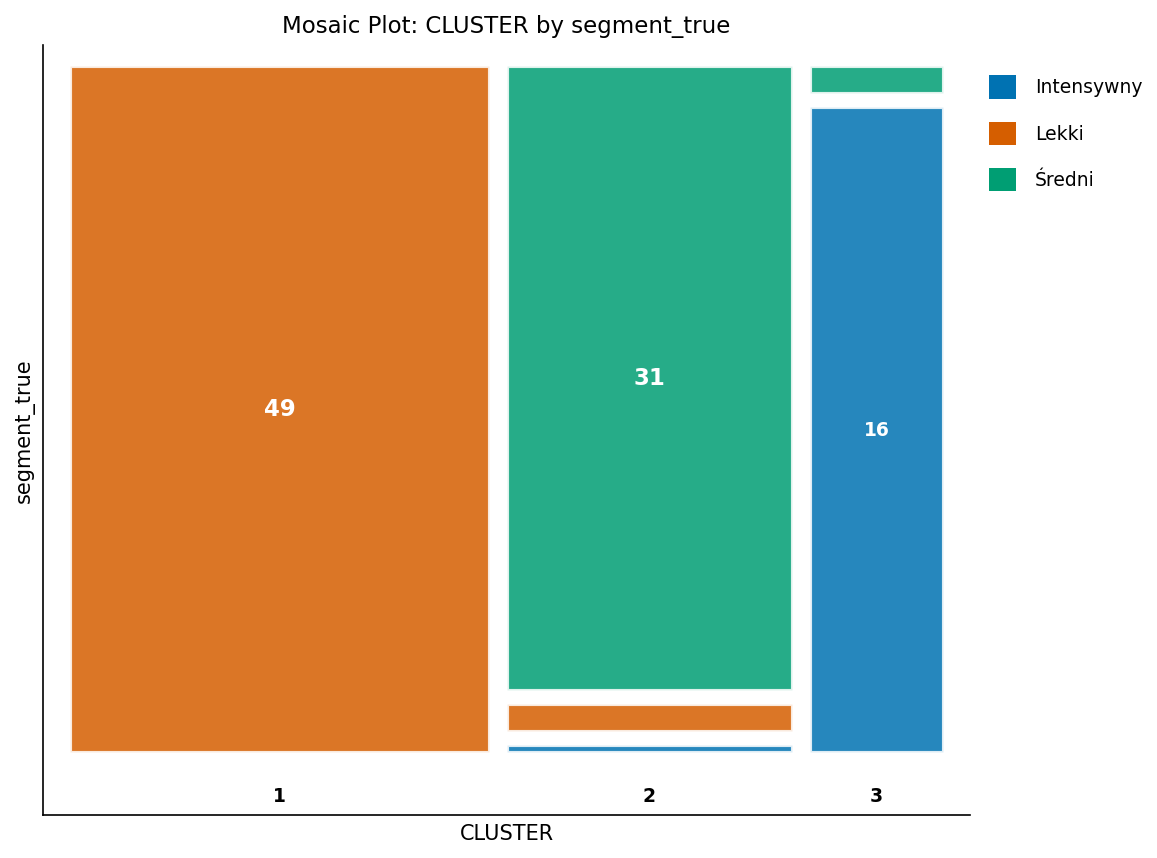

In [6]:
PROCEDURA CZĘSTOŚCI DANE=scored;
   TYTUŁ "Wykryty segment a rzeczywista ukryta warstwa";
   TABLES CLUSTER * segment_true / norow nocol nopercent;
   ETYKIETA CLUSTER="Segment" segment_true="Rzeczywisty segment";
WYKONAJ;
TYTUŁ;

## Interpretacja wyników

**Co znalazł FASTCLUS.** Startując z pojedynczej, prawoskośnej kolumny użycia
bez etykiet, rozwiązanie k-średnich z trzema klastrami wyjaśniło **89,9%**
wariancji log-zużycia (ogólne R² = 0,899, pseudo-F = 431) i podzieliło
abonentów na segment **lekki** (średnia 3,1 GB, n = 49), segment **średni**
(średnia 12,8 GB, n = 34) i segment **intensywny** (średnia 45,4 GB, n = 17).
Krzyżowanie z wyłączoną wcześniej `segment_true` odzyskało zasadzoną strukturę
niemal dokładnie — **96 ze 100** abonentów trafiło do klastra zgodnego z ich
warstwą generującą (Lekki 49/49, Średni 31/34, Intensywny 16/17).

**Dlaczego skala logarytmiczna.** Zużycie danych jest ściśle dodatnie i ma
ciężki ogon; klastrowanie `log_gb` utrzymuje sensowność odległości euklidesowych
i dobrą separację średnich segmentów, podczas gdy odwrotna transformacja
wykładnicza odtwarza realistyczną skośność w skali GB.

**Dlaczego ma to znaczenie operacyjne.** Każdy abonent opuszcza model z twardą
etykietą segmentu *i* wynikiem odległości od centroidu, dzięki czemu operator
może działać z wykalibrowaną pewnością — pewnie kierować oferty premium do
centralnych intensywnych użytkowników i oznaczać granicznych klientów (duża
odległość) do bliższego przyjrzenia się. Średni staż różni się także między
wykrytymi segmentami, co daje punkt zaczepienia dla cyklu życia klienta i
harmonogramu up-sellingu.

**Wybór liczby segmentów.** Porównanie `MAXCLUSTERS=` 2, 3 i 4 według
ogólnego R² i pseudo-F to przejrzysty, powtarzalny sposób wyboru *k*: duży
zysk przy trzech klastrach i jedynie kosmetyczny zysk przy czterech (który
dzieli warstwę lekką) uczyniły trzy klastry uzasadnionym wyborem w tym
przypadku.

**Związek ze skończonymi modelami mieszanek.** Skończony model mieszanek
(PROC HPFMM / PROC FMM) dodałby miękkie przynależności posterior i oparte na
wiarygodności BIC dla liczby składników. Te procedury nie są jeszcze
numerycznie zaimplementowane w tej wersji; PROC FASTCLUS dostarcza tę samą
praktyczną segmentację — odkrycie, charakterystykę, twarde przypisanie i
miarę pewności — w pełni numerycznym, powtarzalnym wynikiem już dziś.